# NexusCommerce: general forecasting and store personalization

Run cells from top to bottom. Add **Store Item Demand Forecasting Challenge** through Kaggle's **Add Input**. Enable Internet only if you need to install missing packages. CPU is sufficient; this notebook does not require GPU.

**Question:** does adapting a general model to a previously excluded store improve future product forecasts?

- General learning: stores 1–9, dates through December 2016.
- Personalization: store 10, dates through December 2016.
- Choose the method: January–June 2017.
- Final exam: July–December 2017. Do not tune settings after inspecting this exam; a new untouched period would be needed.
- Forecast 7, 14 and 30 days using only information available at each starting date. Actual sales from later starting dates become available normally, but no model is retrained during evaluation.

These stores are benchmark data, not proof of performance across independent businesses or countries. We will evaluate M5 separately afterward. Current application models are never overwritten.


In [2]:
# Kaggle normally includes these libraries. Do not upgrade automatically.
# If an import fails, uncomment the following line, run it, then restart the session:
# %pip install -q xgboost pandas numpy
import sys
import numpy as np
import pandas as pd
import xgboost as xgb
print('Python:', sys.version)
print('XGBoost:', xgb.__version__, 'pandas:', pd.__version__, 'NumPy:', np.__version__)


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
XGBoost: 3.4.1 pandas: 2.3.3 NumPy: 2.1.3


## Shared forecasting code
This is the same code checked locally. It scales sales by their earlier 28-day average, uses earlier sales only, and explicitly continues the general model for the personalized candidate. IDs identify histories but are not numeric forecasting inputs.


In [3]:
"""Store-item forecasting experiment. Never writes to the application's ml/models.

Training: source stores through 2016; adaptation: held-out store through 2016.
Selection: Jan-Jun 2017; untouched final evaluation: Jul-Dec 2017.
All horizons use recursive forecasts, not future actual sales as input.
"""
from dataclasses import asdict, dataclass
from pathlib import Path
import argparse
import json

import numpy as np
import pandas as pd
import xgboost as xgb


@dataclass
class Config:
    target_store: int = 10
    train_end: str = "2016-12-31"
    validation_end: str = "2017-06-30"
    test_end: str = "2017-12-31"
    horizon: int = 30
    origin_stride: int = 30
    general_trees: int = 250
    adaptation_trees: int = 80
    n_jobs: int = 4
    min_relative_improvement: float = 0.02
    seed: int = 42


def locate_data():
    local = Path(__file__).resolve().parents[2] / "data/store_item_demand" if "__file__" in globals() else None
    roots = [Path("/kaggle/input")]
    if local is not None:
        roots.append(local)
    matches = []
    for root in roots:
        if root.exists():
            matches.extend(root.rglob("train.csv"))
            matches.extend(root.rglob("train.csv.zip"))
    for path in sorted(matches):
        if set(pd.read_csv(path, nrows=0).columns) == {"date", "store", "item", "sales"}:
            return path
    raise FileNotFoundError("Add Store Item Demand Forecasting Challenge to the notebook, or set DATA_PATH manually.")


def load_data(path):
    data = pd.read_csv(path, usecols=["date", "store", "item", "sales"])
    data["date"] = pd.to_datetime(data["date"], errors="raise")
    if data.isna().any().any() or not np.isfinite(data.sales).all() or (data.sales < 0).any():
        raise ValueError("Missing, non-finite or negative values require an explicit cleaning policy.")
    if data.duplicated(["store", "item", "date"]).any():
        raise ValueError("Duplicate store/item/day rows: investigate before aggregating.")
    data = data.sort_values(["store", "item", "date"]).reset_index(drop=True)
    for key, group in data.groupby(["store", "item"], sort=False):
        if not group.date.diff().dropna().eq(pd.Timedelta(days=1)).all():
            raise ValueError(f"Missing calendar days in series {key}; do not silently fill with zero.")
    return data


def features_for_series(group):
    """Shared training/inference features. Current-day sales never enter inputs.

    Scale is the previous 28-day mean + 1. Target is sales/scale.
    No store or item ID is an input, allowing the model to work on unseen series.
    """
    group = group.sort_values("date")
    sales = group.sales.astype(float)
    past = sales.shift(1)
    scale = past.rolling(28, min_periods=28).mean() + 1.0
    result = pd.DataFrame(index=group.index)
    dates = group.date.dt
    result["day_of_week"] = dates.dayofweek
    result["month"] = dates.month
    result["is_weekend"] = (dates.dayofweek >= 5).astype(int)
    result["dow_sin"] = np.sin(2 * np.pi * dates.dayofweek / 7)
    result["dow_cos"] = np.cos(2 * np.pi * dates.dayofweek / 7)
    result["doy_sin"] = np.sin(2 * np.pi * dates.dayofyear / 365.25)
    result["doy_cos"] = np.cos(2 * np.pi * dates.dayofyear / 365.25)
    for lag in [1, 2, 7, 14, 28]:
        result[f"lag_{lag}_relative"] = sales.shift(lag) / scale
    for window in [7, 14, 28]:
        rolling = past.rolling(window, min_periods=window)
        result[f"mean_{window}_relative"] = rolling.mean() / scale
        result[f"std_{window}_relative"] = rolling.std(ddof=0) / scale
    result["trend_7_relative"] = (sales.shift(1) - sales.shift(8)) / scale
    result["scale"] = scale
    result["target"] = sales / scale
    return result


def make_training_frame(data):
    parts = []
    for _, group in data.groupby(["store", "item"], sort=False):
        frame = features_for_series(group)
        frame[["date", "store", "item"]] = group[["date", "store", "item"]]
        parts.append(frame)
    return pd.concat(parts).dropna().reset_index(drop=True)


def new_model(trees, config):
    return xgb.XGBRegressor(
        n_estimators=trees, max_depth=5, learning_rate=0.04,
        min_child_weight=10, subsample=0.85, colsample_bytree=0.9,
        reg_lambda=5, objective="reg:squarederror", tree_method="hist",
        n_jobs=config.n_jobs, random_state=config.seed,
    )


def train_candidates(data, config):
    # Split raw dates BEFORE building any training frame.
    history = data.loc[data.date <= pd.Timestamp(config.train_end)]
    if config.target_store not in set(history.store) or history.store.nunique() < 2:
        raise ValueError("Need a target store and at least one different source store.")
    frame = make_training_frame(history)
    feature_names = [c for c in frame if c not in ["date", "store", "item", "scale", "target"]]
    source = frame.loc[frame.store != config.target_store]
    target = frame.loc[frame.store == config.target_store]
    if source.empty or target.empty:
        raise ValueError("Not enough earlier history to build training features.")
    general = new_model(config.general_trees, config)
    general.fit(source[feature_names].astype("float32"), source.target.astype("float32"))
    personalized = new_model(config.adaptation_trees, config)
    # Explicit continuation from the loaded booster; not a constructor parameter.
    personalized.fit(target[feature_names].astype("float32"), target.target.astype("float32"),
                     xgb_model=general.get_booster())
    if personalized.get_booster().num_boosted_rounds() != config.general_trees + config.adaptation_trees:
        raise AssertionError("Personalization did not continue the base model.")
    print(f"General training rows: {len(source):,}; target-store adaptation rows: {len(target):,}")
    return {"general": general, "personalized": personalized}, feature_names


def forecast_models(history, models, feature_names, horizon):
    """Forecast next dates for each item; only predictions extend its history."""
    states = {name: {item: g[["date", "sales"]].copy().reset_index(drop=True)
                     for item, g in history.groupby("item", sort=True)} for name in models}
    rows = []
    for step in range(1, horizon + 1):
        for name, model in models.items():
            inputs, scales, dates, items = [], [], [], []
            for item, group in states[name].items():
                next_date = group.date.iloc[-1] + pd.Timedelta(days=1)
                # Placeholder sales are excluded by all lag/rolling features.
                extended = pd.concat([group, pd.DataFrame({"date": [next_date], "sales": [0.]})], ignore_index=True)
                next_features = features_for_series(extended).iloc[-1]
                if next_features[feature_names + ["scale"]].isna().any():
                    raise ValueError("At least 28 complete historical days are required.")
                inputs.append(next_features[feature_names].to_numpy())
                scales.append(next_features["scale"])
                dates.append(next_date)
                items.append(item)
            predictions = np.maximum(0, model.predict(pd.DataFrame(inputs, columns=feature_names).astype("float32")) * np.asarray(scales))
            for item, date, prediction in zip(items, dates, predictions):
                rows.append({"item": item, "date": date, "step": step, "method": name, "predicted": float(prediction)})
                # Retain sufficient actual/predicted history for the 28-day features.
                states[name][item] = pd.concat([states[name][item], pd.DataFrame({"date": [date], "sales": [prediction]})], ignore_index=True).tail(60)
    return pd.DataFrame(rows)


def forecast_baselines(history, horizon):
    rows = []
    for item, group in history.groupby("item", sort=True):
        dates, values = group.date, group.sales.to_list()
        moving_mean = float(np.mean(values[-7:]))
        seasonal = values[-7:].copy()
        for step in range(1, horizon + 1):
            date = dates.iloc[-1] + pd.Timedelta(days=step)
            for name, value in [("seasonal_naive", seasonal[(step - 1) % 7]), ("moving_average", moving_mean)]:
                rows.append({"item": item, "date": date, "step": step, "method": name, "predicted": value})
    return pd.DataFrame(rows)


def backtest(data, models, feature_names, config, start, end, period):
    target = data.loc[data.store == config.target_store]
    origins = pd.date_range(start, pd.Timestamp(end) - pd.Timedelta(days=config.horizon - 1), freq=f"{config.origin_stride}D")
    if len(origins) < 2:
        raise ValueError("Need at least two complete forecast windows in each evaluation period.")
    results = []
    for origin in origins:
        print(f"{period}: forecast starting {origin.date()}", flush=True)
        # No rows on/after origin are passed to either forecast function.
        history = target.loc[target.date < origin]
        predicted = pd.concat([forecast_models(history, models, feature_names, config.horizon),
                               forecast_baselines(history, config.horizon)], ignore_index=True)
        observed = target[["item", "date", "sales"]].rename(columns={"sales": "actual"})
        scored = predicted.merge(observed, on=["item", "date"], how="left", validate="many_to_one")
        if scored.actual.isna().any():
            raise ValueError("Forecast window extends beyond available observations.")
        scored["origin"] = origin
        scored["period"] = period
        results.append(scored)
    return pd.concat(results, ignore_index=True)


def metrics_table(predictions):
    rows = []
    for horizon in [7, 14, 30]:
        subset = predictions.loc[predictions.step <= horizon]
        for method, group in subset.groupby("method"):
            error = group.predicted.to_numpy() - group.actual.to_numpy()
            total = float(group.actual.sum())
            rows.append({"horizon": horizon, "method": method, "MAE": float(np.abs(error).mean()),
                         "RMSE": float(np.sqrt(np.mean(error ** 2))),
                         "WAPE_percent": float(100 * np.abs(error).sum() / total) if total else np.nan,
                         "bias_percent": float(100 * error.sum() / total) if total else np.nan,
                         "observations": len(group), "origins": group.origin.nunique()})
    return pd.DataFrame(rows)


def select_methods(validation_metrics, config):
    selection = {}
    for horizon, group in validation_metrics.groupby("horizon"):
        scores = group.set_index("method").WAPE_percent
        if scores.isna().any():
            raise ValueError("Cannot select methods when all actual sales are zero.")
        non_personalized = scores.drop("personalized").idxmin()
        enough_gain = scores.personalized < scores[non_personalized] * (1 - config.min_relative_improvement)
        selection[int(horizon)] = "personalized" if enough_gain else non_personalized
    return selection


def run_experiment(data, output_dir, config):
    if config.horizon != 30 or config.origin_stride < 30:
        raise ValueError("Use 30-day maximum horizon and non-overlapping origins at least 30 days apart.")
    if not pd.Timestamp(config.train_end) < pd.Timestamp(config.validation_end) < pd.Timestamp(config.test_end):
        raise ValueError("Training, validation and final test must be chronological.")
    models, feature_names = train_candidates(data, config)
    validation_start = pd.Timestamp(config.train_end) + pd.Timedelta(days=1)
    validation = backtest(data, models, feature_names, config, validation_start, config.validation_end, "validation")
    validation_metrics = metrics_table(validation)
    selected = select_methods(validation_metrics, config)
    print("Methods chosen using VALIDATION ONLY:", selected)
    test_start = pd.Timestamp(config.validation_end) + pd.Timedelta(days=1)
    final_test = backtest(data, models, feature_names, config, test_start, config.test_end, "final_test")
    test_metrics = metrics_table(final_test)
    selected_results = test_metrics.loc[test_metrics.apply(lambda row: selected[row.horizon] == row.method, axis=1)]
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    for name, model in models.items():
        model.save_model(output_dir / f"{name}.json")
    manifest = {"config": asdict(config), "features": feature_names, "selected_by_horizon": selected,
                "scale": "previous 28-day mean sales + 1", "target": "sales / scale",
                "xgboost_version": xgb.__version__, "pandas_version": pd.__version__,
                "training_countries": "Not available in this dataset; do not claim cross-country validation.",
                "scope": "One held-out store; repeat with other stores before claiming general personalization gains.",
                "runtime": "Experimental schema; requires a matching inference adapter before app integration."}
    (output_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    validation_metrics.to_csv(output_dir / "validation_metrics.csv", index=False)
    test_metrics.to_csv(output_dir / "final_test_metrics.csv", index=False)
    selected_results.to_csv(output_dir / "selected_final_test_metrics.csv", index=False)
    pd.concat([validation, final_test]).to_csv(output_dir / "forecast_predictions.csv", index=False)
    # Per-item errors prevent good total scores from hiding weak products.
    per_item = []
    for (method, item), group in final_test.groupby(["method", "item"]):
        total = group.actual.sum()
        per_item.append({"method": method, "item": item, "MAE": (group.predicted - group.actual).abs().mean(),
                         "WAPE_percent": 100 * (group.predicted - group.actual).abs().sum() / total if total else np.nan})
    pd.DataFrame(per_item).to_csv(output_dir / "per_item_final_test.csv", index=False)
    print("\nFinal test (lower error is better):\n", test_metrics.round(3).to_string(index=False))
    print("\nChosen methods on final test:\n", selected_results.round(3).to_string(index=False))
    print("Results saved to", output_dir)
    return validation_metrics, test_metrics, selected



## Load and check the data
Keep `DATA_PATH = None` for automatic detection. Only use this notebook with the store-item dataset; M5 needs its own adapter. Missing days and duplicate store/item/date rows cause a clear error rather than silently changing sales.


In [4]:
DATA_PATH = None  # Or '/kaggle/input/.../train.csv'
data_path = Path(DATA_PATH) if DATA_PATH else locate_data()
data = load_data(data_path)
print('File:', data_path)
print('Rows:', len(data), 'Stores:', data.store.nunique(), 'Items:', data.item.nunique())
print('Dates:', data.date.min(), 'to', data.date.max())
display(data.head())


File: /kaggle/input/datasets/abdullahkhan001187/store-item-demand-forecasting-challenge/train.csv
Rows: 913000 Stores: 10 Items: 50
Dates: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Train and run the fair comparison
Leave `SMOKE_TEST = False` for the full experiment. True runs a small code check (2 products, 2 source stores, few trees); its metrics must not be used as your FYP results.

WAPE is total absolute error divided by total actual sales; lower is better. It includes zero-sales observations. Bias shows over/under-prediction. Personalized forecasts are chosen only when they beat the best alternative by at least 2% relative WAPE on validation. Baselines can win. Results are selected separately for each horizon.


In [5]:
SMOKE_TEST = False
config = Config()
experiment_data = data
if SMOKE_TEST:
    experiment_data = data.loc[data.store.isin([1, 2, 10]) & data.item.isin([1, 2])].copy()
    config.general_trees = 8
    config.adaptation_trees = 4
    config.n_jobs = 2
OUTPUT_DIR = Path('/kaggle/working/nexus_store_personalization')
validation_metrics, final_test_metrics, selected_methods = run_experiment(experiment_data, OUTPUT_DIR, config)


General training rows: 644,850; target-store adaptation rows: 71,650
validation: forecast starting 2017-01-01
validation: forecast starting 2017-01-31
validation: forecast starting 2017-03-02
validation: forecast starting 2017-04-01
validation: forecast starting 2017-05-01
validation: forecast starting 2017-05-31
Methods chosen using VALIDATION ONLY: {7: 'general', 14: 'general', 30: 'general'}
final_test: forecast starting 2017-07-01
final_test: forecast starting 2017-07-31
final_test: forecast starting 2017-08-30
final_test: forecast starting 2017-09-29
final_test: forecast starting 2017-10-29
final_test: forecast starting 2017-11-28

Final test (lower error is better):
  horizon         method    MAE   RMSE  WAPE_percent  bias_percent  observations  origins
       7        general  6.778  8.757         9.618        -0.132          2100        6
       7 moving_average 11.426 14.850        16.215         4.628          2100        6
       7   personalized  6.773  8.742         9.612

## Read the results
Compare validation and final-test errors. If personalization does not help, report that honestly. A result for store 10 alone is not a general claim: repeat with other target stores as independent experiments, using the same settings rather than optimizing on their final-test results.

This first experiment has no prediction intervals, country data, promotions or prices. It estimates recorded sales rather than unconstrained demand during stockouts. Do not claim those features were validated.


,horizon,method,MAE,RMSE,WAPE_percent,bias_percent,observations,origins
0,7,general,6.484,8.423,10.316,-1.104,2100,6
1,7,moving_average,10.450,13.873,16.626,-7.632,2100,6
2,7,personalized,6.462,8.391,10.281,-0.887,2100,6
3,7,seasonal_naive,10.110,13.259,16.084,-7.632,2100,6
4,14,general,6.471,8.378,10.282,-0.680,4200,6
5,14,moving_average,10.359,13.829,16.458,-7.755,4200,6
6,14,personalized,6.461,8.359,10.265,-0.470,4200,6
7,14,seasonal_naive,10.122,13.178,16.082,-7.755,4200,6
8,30,general,6.471,8.382,10.276,-0.203,9000,6
9,30,moving_average,10.487,14.003,16.653,-7.807,9000,6


,horizon,method,MAE,RMSE,WAPE_percent,bias_percent,observations,origins
0,7,general,6.778,8.757,9.618,-0.132,2100,6
1,7,moving_average,11.426,14.850,16.215,4.628,2100,6
2,7,personalized,6.773,8.742,9.612,0.114,2100,6
3,7,seasonal_naive,11.293,14.800,16.026,4.628,2100,6
4,14,general,6.701,8.616,9.625,-0.279,4200,6
5,14,moving_average,12.137,15.729,17.431,5.885,4200,6
6,14,personalized,6.698,8.605,9.619,-0.106,4200,6
7,14,seasonal_naive,11.634,15.162,16.709,5.885,4200,6
8,30,general,6.538,8.418,9.446,-0.342,9000,6
9,30,moving_average,12.558,16.256,18.144,6.518,9000,6


Selected from validation: {7: 'general', 14: 'general', 30: 'general'}


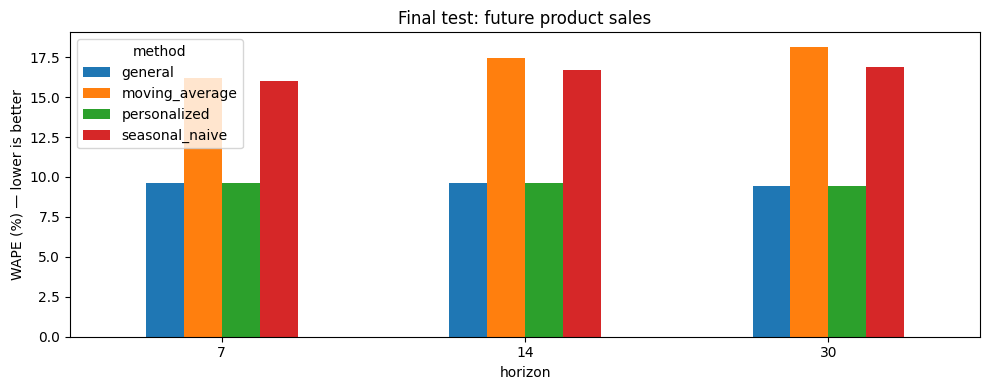

In [6]:
display(validation_metrics.round(3))
display(final_test_metrics.round(3))
print('Selected from validation:', selected_methods)
import matplotlib.pyplot as plt
comparison = final_test_metrics.pivot(index='horizon', columns='method', values='WAPE_percent')
comparison.plot.bar(figsize=(10, 4), ylabel='WAPE (%) — lower is better', title='Final test: future product sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'final_test_comparison.png', dpi=150)
plt.show()


## Download the artifacts
The ZIP includes general and personalized models in XGBoost JSON format, feature/configuration metadata, validation/final-test metrics and forecast rows. **Do not copy these models into `ml/models` yet:** their normalized features differ from the old application's schema. We must add a matching inference adapter and test integration first.


In [7]:
import shutil
archive = shutil.make_archive('/kaggle/working/nexus_store_personalization', 'zip', OUTPUT_DIR)
print('Download from Kaggle Output:', archive)


Download from Kaggle Output: /kaggle/working/nexus_store_personalization.zip
